1.a -->Equation 10.12 is:

$$\frac{1}{|C_{k}|} \sum_{i,i' \in C_{k}} \sum_{j=1}^{p}(x_{ij}-x_{i'j})^{2} 
= 2\sum_{i \in C_{k}} \sum_{j=1}^{p} (x_{ij}-\bar x_{kj})^{2} $$

$$LHS = \frac{1}{|C_{k}|} \sum_{i,i' \in C_{k}} \sum_{j=1}^{p}(x_{ij}-x_{i'j})^{2} =\frac{1}{|C_{k}|} \sum_{i,i' \in C_{k}}\sum_{j=1}^{p} x_{ij}^{2}-\frac{2}{|C_{k}|} \sum_{i,i' \in C_{k}}\sum_{j=1}^{p} x_{ij}x_{i'j}+\frac{1}{|C_{k}|} \sum_{i,i' \in C_{k}}\sum_{j=1}^{p} x_{i'j}^{2} $$
$$ = 2 \sum_{i \in C_{k}}\sum_{j=1}^{p} x_{ij}^{2}-\frac{2}{|C_{k}|} \sum_{i,i' \in C_{k}}\sum_{j=1}^{p} x_{ij}x_{i'j} $$

$$RHS = 2\sum_{i \in C_{k}} \sum_{j=1}^{p} (x_{ij}-\bar x_{kj})^{2} = 2\sum_{i \in C_{k}} \sum_{j=1}^{p} x_{ij}^{2}-4\sum_{i \in C_{k}} \sum_{j=1}^{p}x_{ij} \bar x_{kj}+ 2\sum_{i \in C_{k}} \sum_{j=1}^{p} \bar x_{kj}^{2}$$

$$= 2\sum_{i \in C_{k}} \sum_{j=1}^{p} x_{ij}^{2}-4 |C_{k}|\sum_{j=1}^{p} \bar x_{kj}^2 + 2 |C_{k}|\sum_{j=1}^{p} \bar x_{kj}^{2}$$
$$= 2\sum_{i \in C_{k}} \sum_{j=1}^{p} x_{ij}^{2}-2 |C_{k}|\sum_{j=1}^{p} \bar x_{kj}^2 $$

$$= 2 \sum_{i \in C_{k}}\sum_{j=1}^{p} x_{ij}^{2}-\frac{2}{|C_{k}|} \
sum_{i,i' \in C_{k}}\sum_{j=1}^{p} x_{ij}x_{i'j} $$ 

$$ Given \space x_{kj}=\frac{1}{|C_{k}|} \sum_{i \in C_{k}} x_{ij}  $$

$$ \therefore RHS =LHS $$

1.b --> As K-means clustering algorithm assigns the observations to the clusters to which they are nearest, after each iteration, the value of RHS will decrease (as this quantity is the sum of squared distance of each observation from the cluster mean)  and,as the points becomes closer near each other and near their centroid, the clustering algorithm decreases the objective at each iteration.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import scale
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

from ISLP import load_data

In [3]:
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

In [4]:
from statsmodels.datasets import get_rdataset
USArrests = get_rdataset('USArrests').data


In [5]:
df = USArrests.reset_index().rename(columns={'index': 'State'})
df.rename(columns={'rownames': 'State'}, inplace=True)
df.head()
X = df[['Murder', 'Assault', 'UrbanPop', 'Rape']]

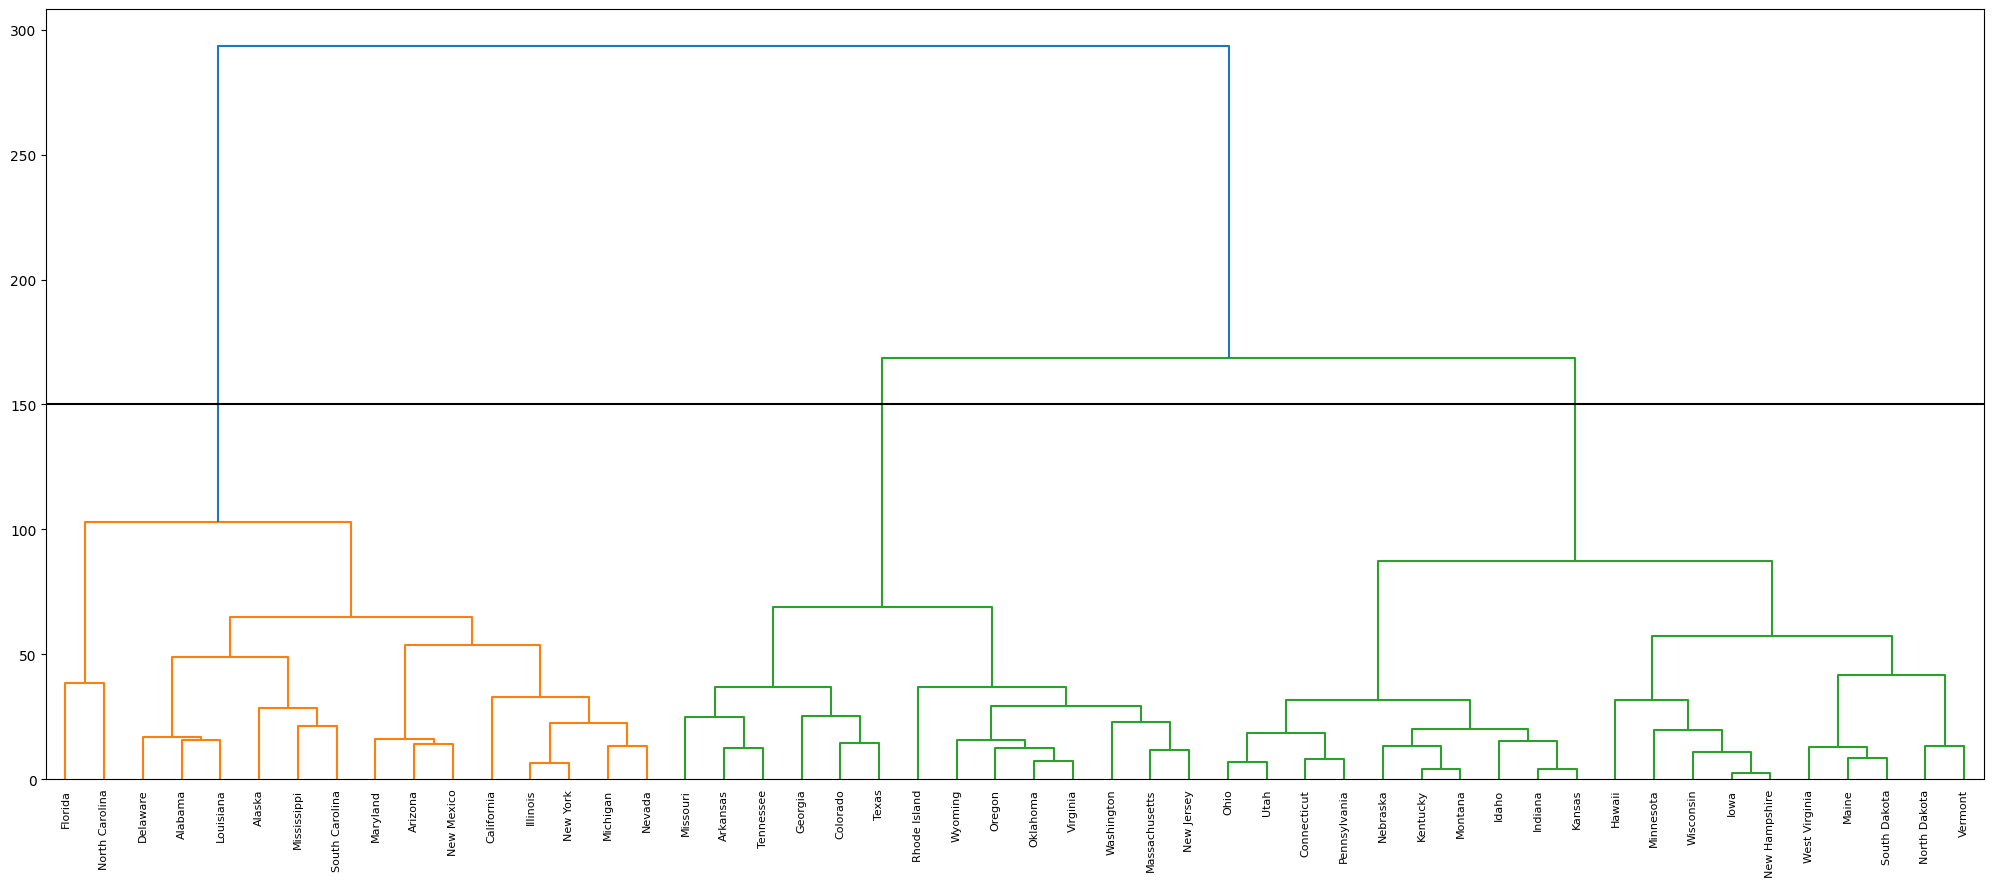

In [7]:
Z = linkage(X, 'complete')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z, labels=df['State'].tolist())
plt.axhline(y=150, c='k')

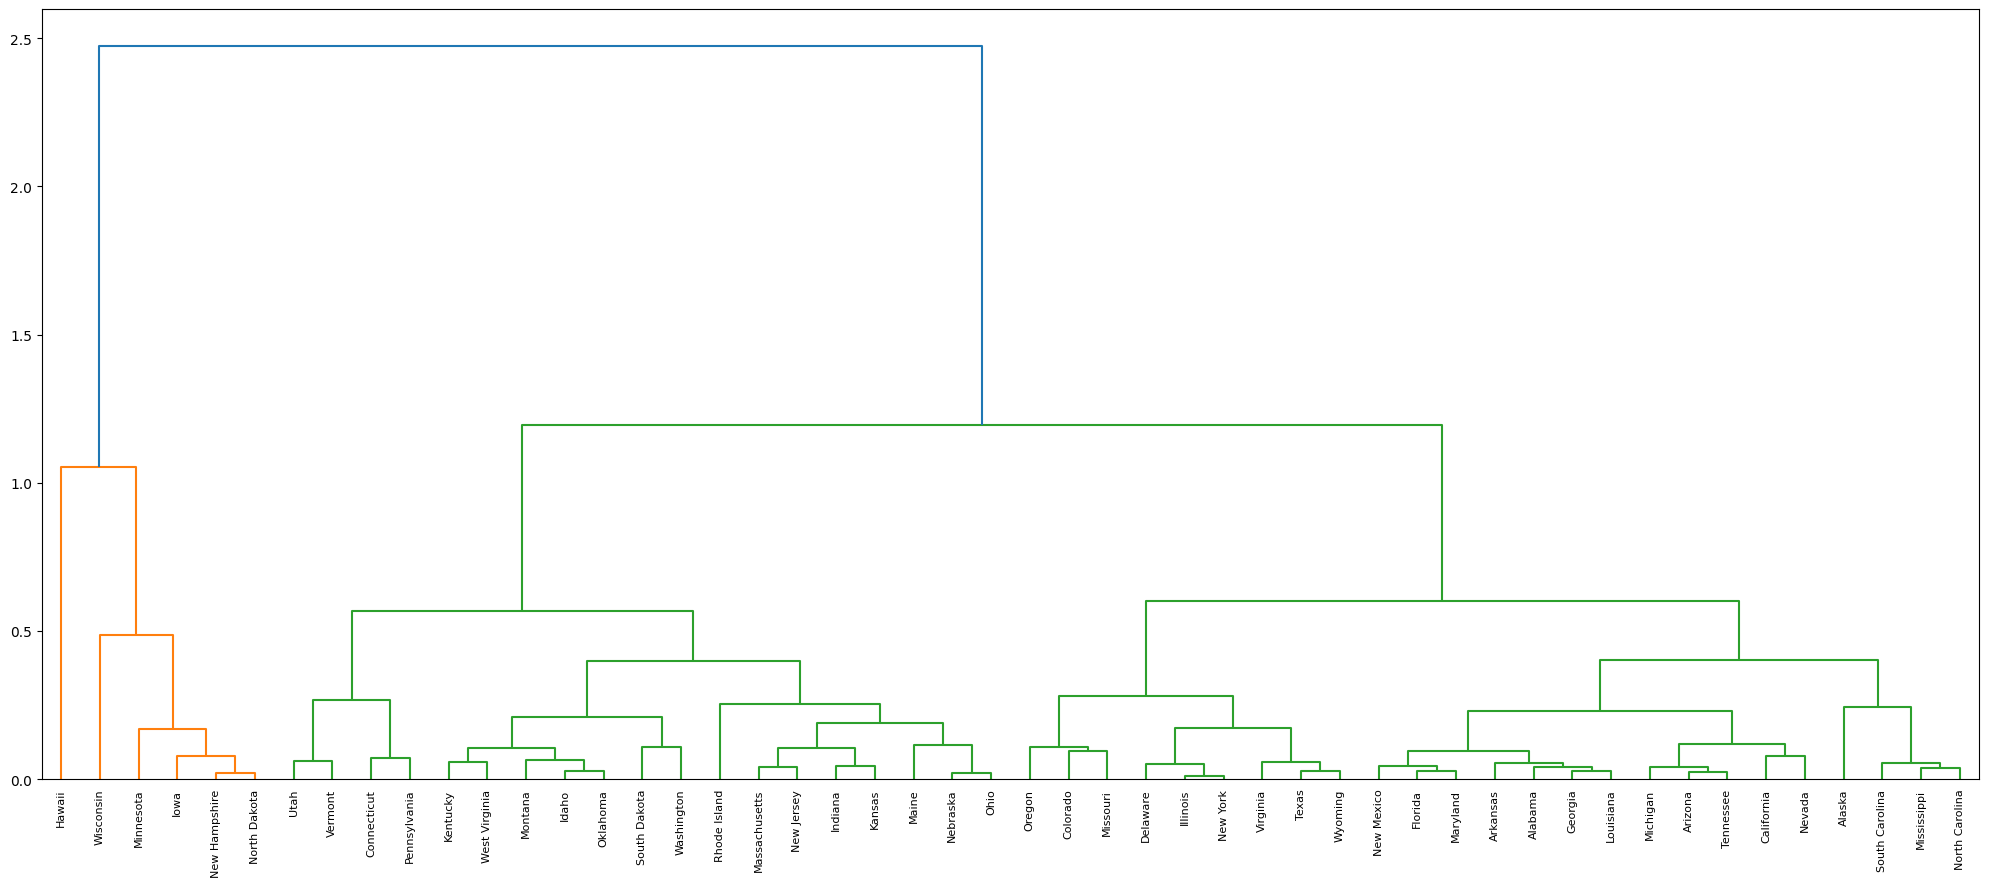

In [8]:
df[['Murder', 'Assault', 'UrbanPop', 'Rape']] = scale(df[['Murder', 'Assault', 'UrbanPop', 'Rape']], axis=1)
X = df[['Murder', 'Assault', 'UrbanPop', 'Rape']]
Z = linkage(X, 'complete')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z, labels=df['State'].tolist())